In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import math

In [18]:
from cycler import cycler

BASE_PATH = Path("/data/shared/fsibilla/clean_code/Q0/fidelity")

EXPERIMENTS = [
    "eth_micron", "lka_micron", "lka_vam",
    "moz_vam", "nga_micron", "nga_mics",
    "yem_mvam", "zwe_mics"
]

EXP_META = {
    "eth_micron": {"label": "Ethiopia ESS",      "color": "#2D7A3A"},
    "lka_micron": {"label": "Sri Lanka HIES",    "color": "#E07B39"},
    "lka_vam":    {"label": "Sri Lanka VAM",     "color": "#4472C4"},
    "moz_vam":    {"label": "Mozambique VAM",    "color": "#C2529A"},
    "nga_micron": {"label": "Nigeria NLSS",      "color": "#8DB33A"},
    "nga_mics":   {"label": "Nigeria MICS",      "color": "#C9A227"},
    "yem_mvam":   {"label": "Yemen mVAM",        "color": "#7B4F2E"},
    "zwe_mics":   {"label": "Zimbabwe MICS",     "color": "#808080"},
}

METRICS      = ["marginal_norm", "bivariate_norm", "joint_norm"]
METRIC_LABELS = ["Marginal", "Bivariate", "Joint"]
MODELS       = ["CTGAN", "TVAE", "cNF"]

# 3 visually distinct colors (not Set2 grey/similar)
MODEL_COLORS = {
    "CTGAN": "#E07B39",   # orange
    "TVAE":  "#4472C4",   # blue
    "cNF":   "#2D7A3A",   # green
}

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [19]:
def load_experiment(exp):
    path = BASE_PATH / exp / "merged_marginal_bivariate_joint_normalized.csv"
    df = pd.read_csv(path)
    # Average over seeds first, then over adm1
    per_seed = df.groupby(["model", "seed"])[METRICS].mean().reset_index()
    mean = per_seed.groupby("model")[METRICS].mean()
    # std across adm1 regions (use original df, grouped by model)
    std = df.groupby("model")[METRICS].std()
    return mean, std

data = {}
for exp in EXPERIMENTS:
    try:
        data[exp] = load_experiment(exp)
    except FileNotFoundError:
        print(f"Missing: {exp}")

In [20]:
def make_spider(ax, means, stds, models, exp_key):
    N = len(METRICS)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles_closed = angles + angles[:1]

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels([])   # hide default labels entirely

    # Place each label manually outside the circle.
    # With theta_offset=pi/2 and direction=-1:
    #   index 0 (Marginal)  → top     → center/bottom
    #   index 1 (Bivariate) → bottom-right → left/top
    #   index 2 (Joint)     → bottom-left  → right/top
    label_r = 1.28
    label_kwargs = [
        dict(ha="center", va="bottom"),   # Marginal — top
        dict(ha="left",   va="top"),      # Bivariate — bottom-right
        dict(ha="right",  va="top"),      # Joint — bottom-left
    ]
    for idx, (angle, label, kw) in enumerate(
            zip(angles, METRIC_LABELS, label_kwargs)):
        ax.text(angle, label_r, label, fontsize=7,
                transform=ax.transData, **kw)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"],
                       fontsize=5, color="grey")
    ax.grid(True, alpha=0.12, linewidth=0.4)

    exp_color = EXPERIMENT_STYLE[exp_key]["color"]
    label_str = EXP_META[exp_key]["label"]
    ax.set_title(label_str,
                 size=9, fontweight="bold", color=exp_color,
                 pad=32,          # title clears the Marginal label
                 linespacing=1.4)

    for model in models:
        if model not in means.index:
            continue
        color = MODEL_COLORS[model]
        vals  = (1 - means.loc[model, METRICS]).tolist()
        errs  = stds.loc[model, METRICS].tolist()
        vals += vals[:1]
        errs += errs[:1]

        ax.plot(angles_closed, vals, color=color, linewidth=1.4,
                linestyle="solid", label=model, alpha=0.9)
        ax.fill(angles_closed, vals, color=color, alpha=0.10)

        upper = [min(v + e, 1.0) for v, e in zip(vals, errs)]
        lower = [max(v - e, 0.0) for v, e in zip(vals, errs)]
        ax.fill_between(angles_closed, lower, upper,
                        color=color, alpha=0.15, linewidth=0)

TypeError: make_spider() takes 5 positional arguments but 6 were given

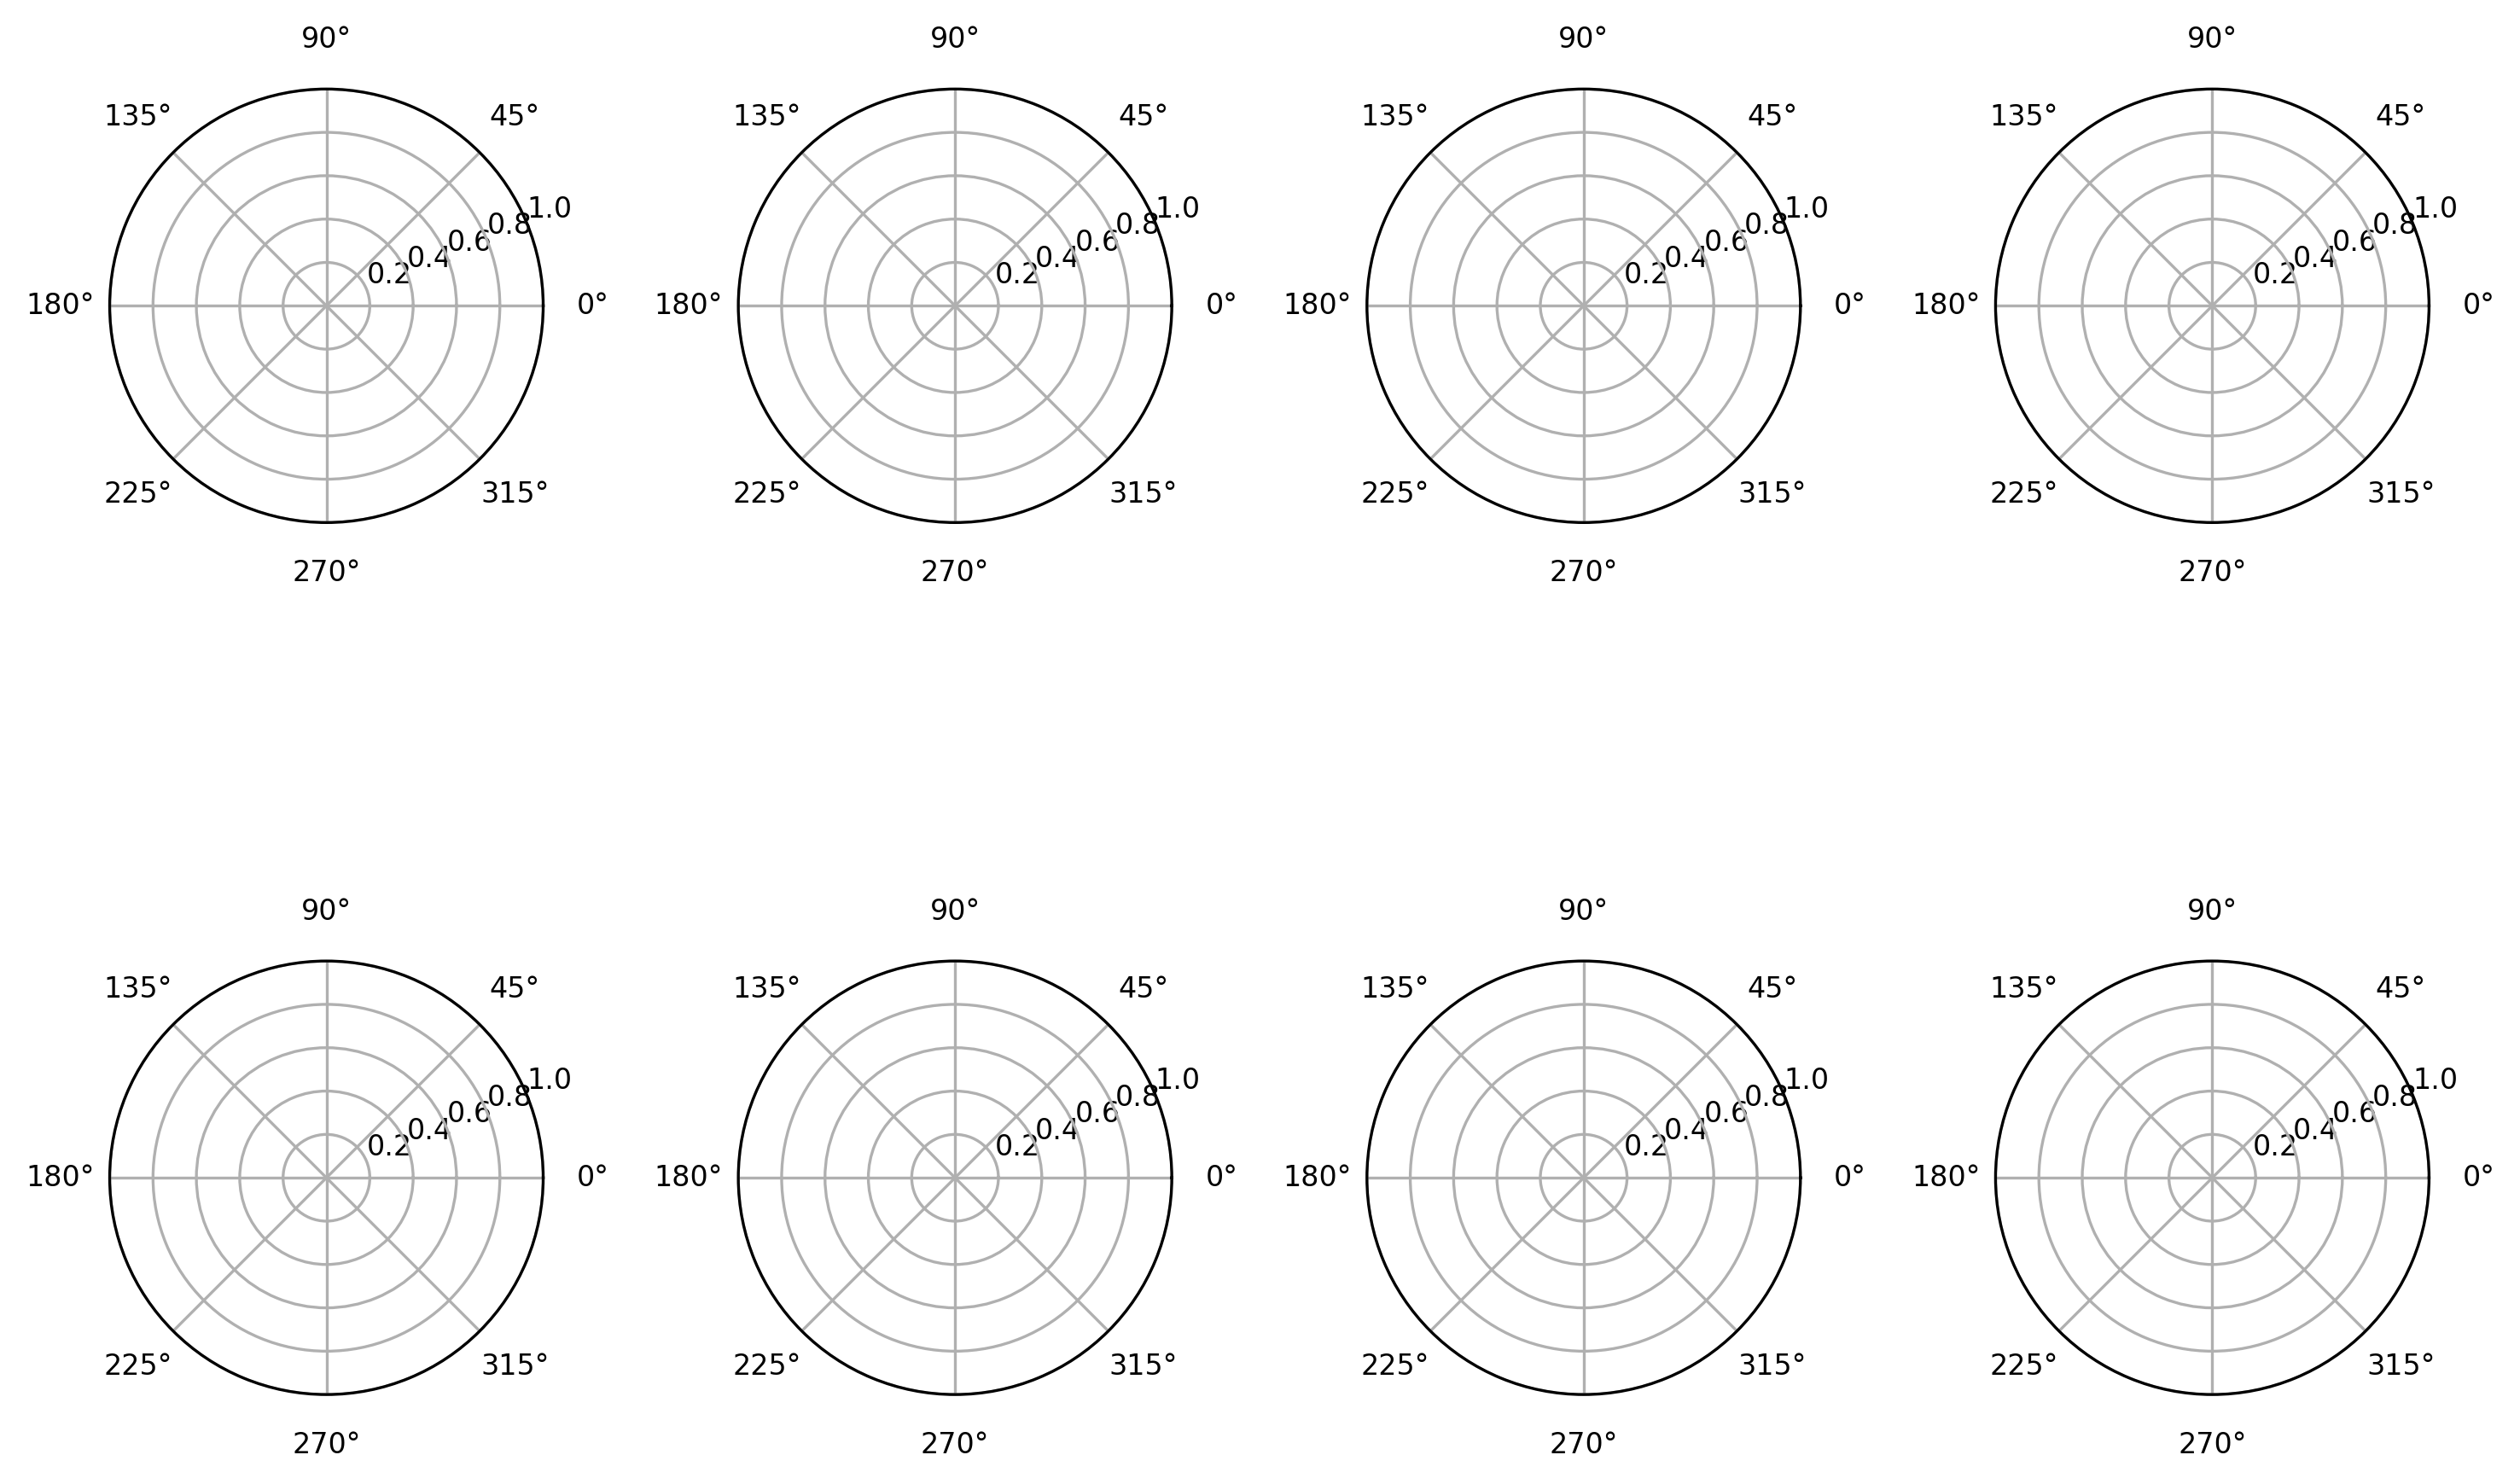

In [21]:
FIG_W, FIG_H = 11.69, 8.27   # A4 landscape
ncols, nrows = 4, 2

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(FIG_W, FIG_H),
    subplot_kw=dict(polar=True),
    gridspec_kw=dict(hspace=0.15, wspace=0.45),  # tight rows
    dpi=300,
)
axes = axes.flatten()

for i, exp in enumerate(EXPERIMENTS):
    ax = axes[i]
    if exp not in data:
        ax.set_visible(False)
        continue
    mean_df, std_df = data[exp]
    make_spider(ax, mean_df, std_df, MODELS, exp, EXP_META[exp]["label"])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# legend — top-left corner of the figure
handles = [
    plt.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=1.4,
               marker='o', markersize=3.5, label=m)
    for m in MODELS
]
fig.legend(
    handles=handles,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    ncol=1,
    frameon=True,
    framealpha=0.92,
    edgecolor="0.82",
    fancybox=False,
    fontsize=7,
    handlelength=1.0,
    handletextpad=0.25,
    labelspacing=0.32,
    borderpad=0.4,
    markerscale=0.8,
)

fig.tight_layout(pad=1.2)
plt.savefig("spider_plots.pdf", bbox_inches="tight", format="pdf")
plt.savefig("spider_plots.png", dpi=300, bbox_inches="tight")
plt.show()

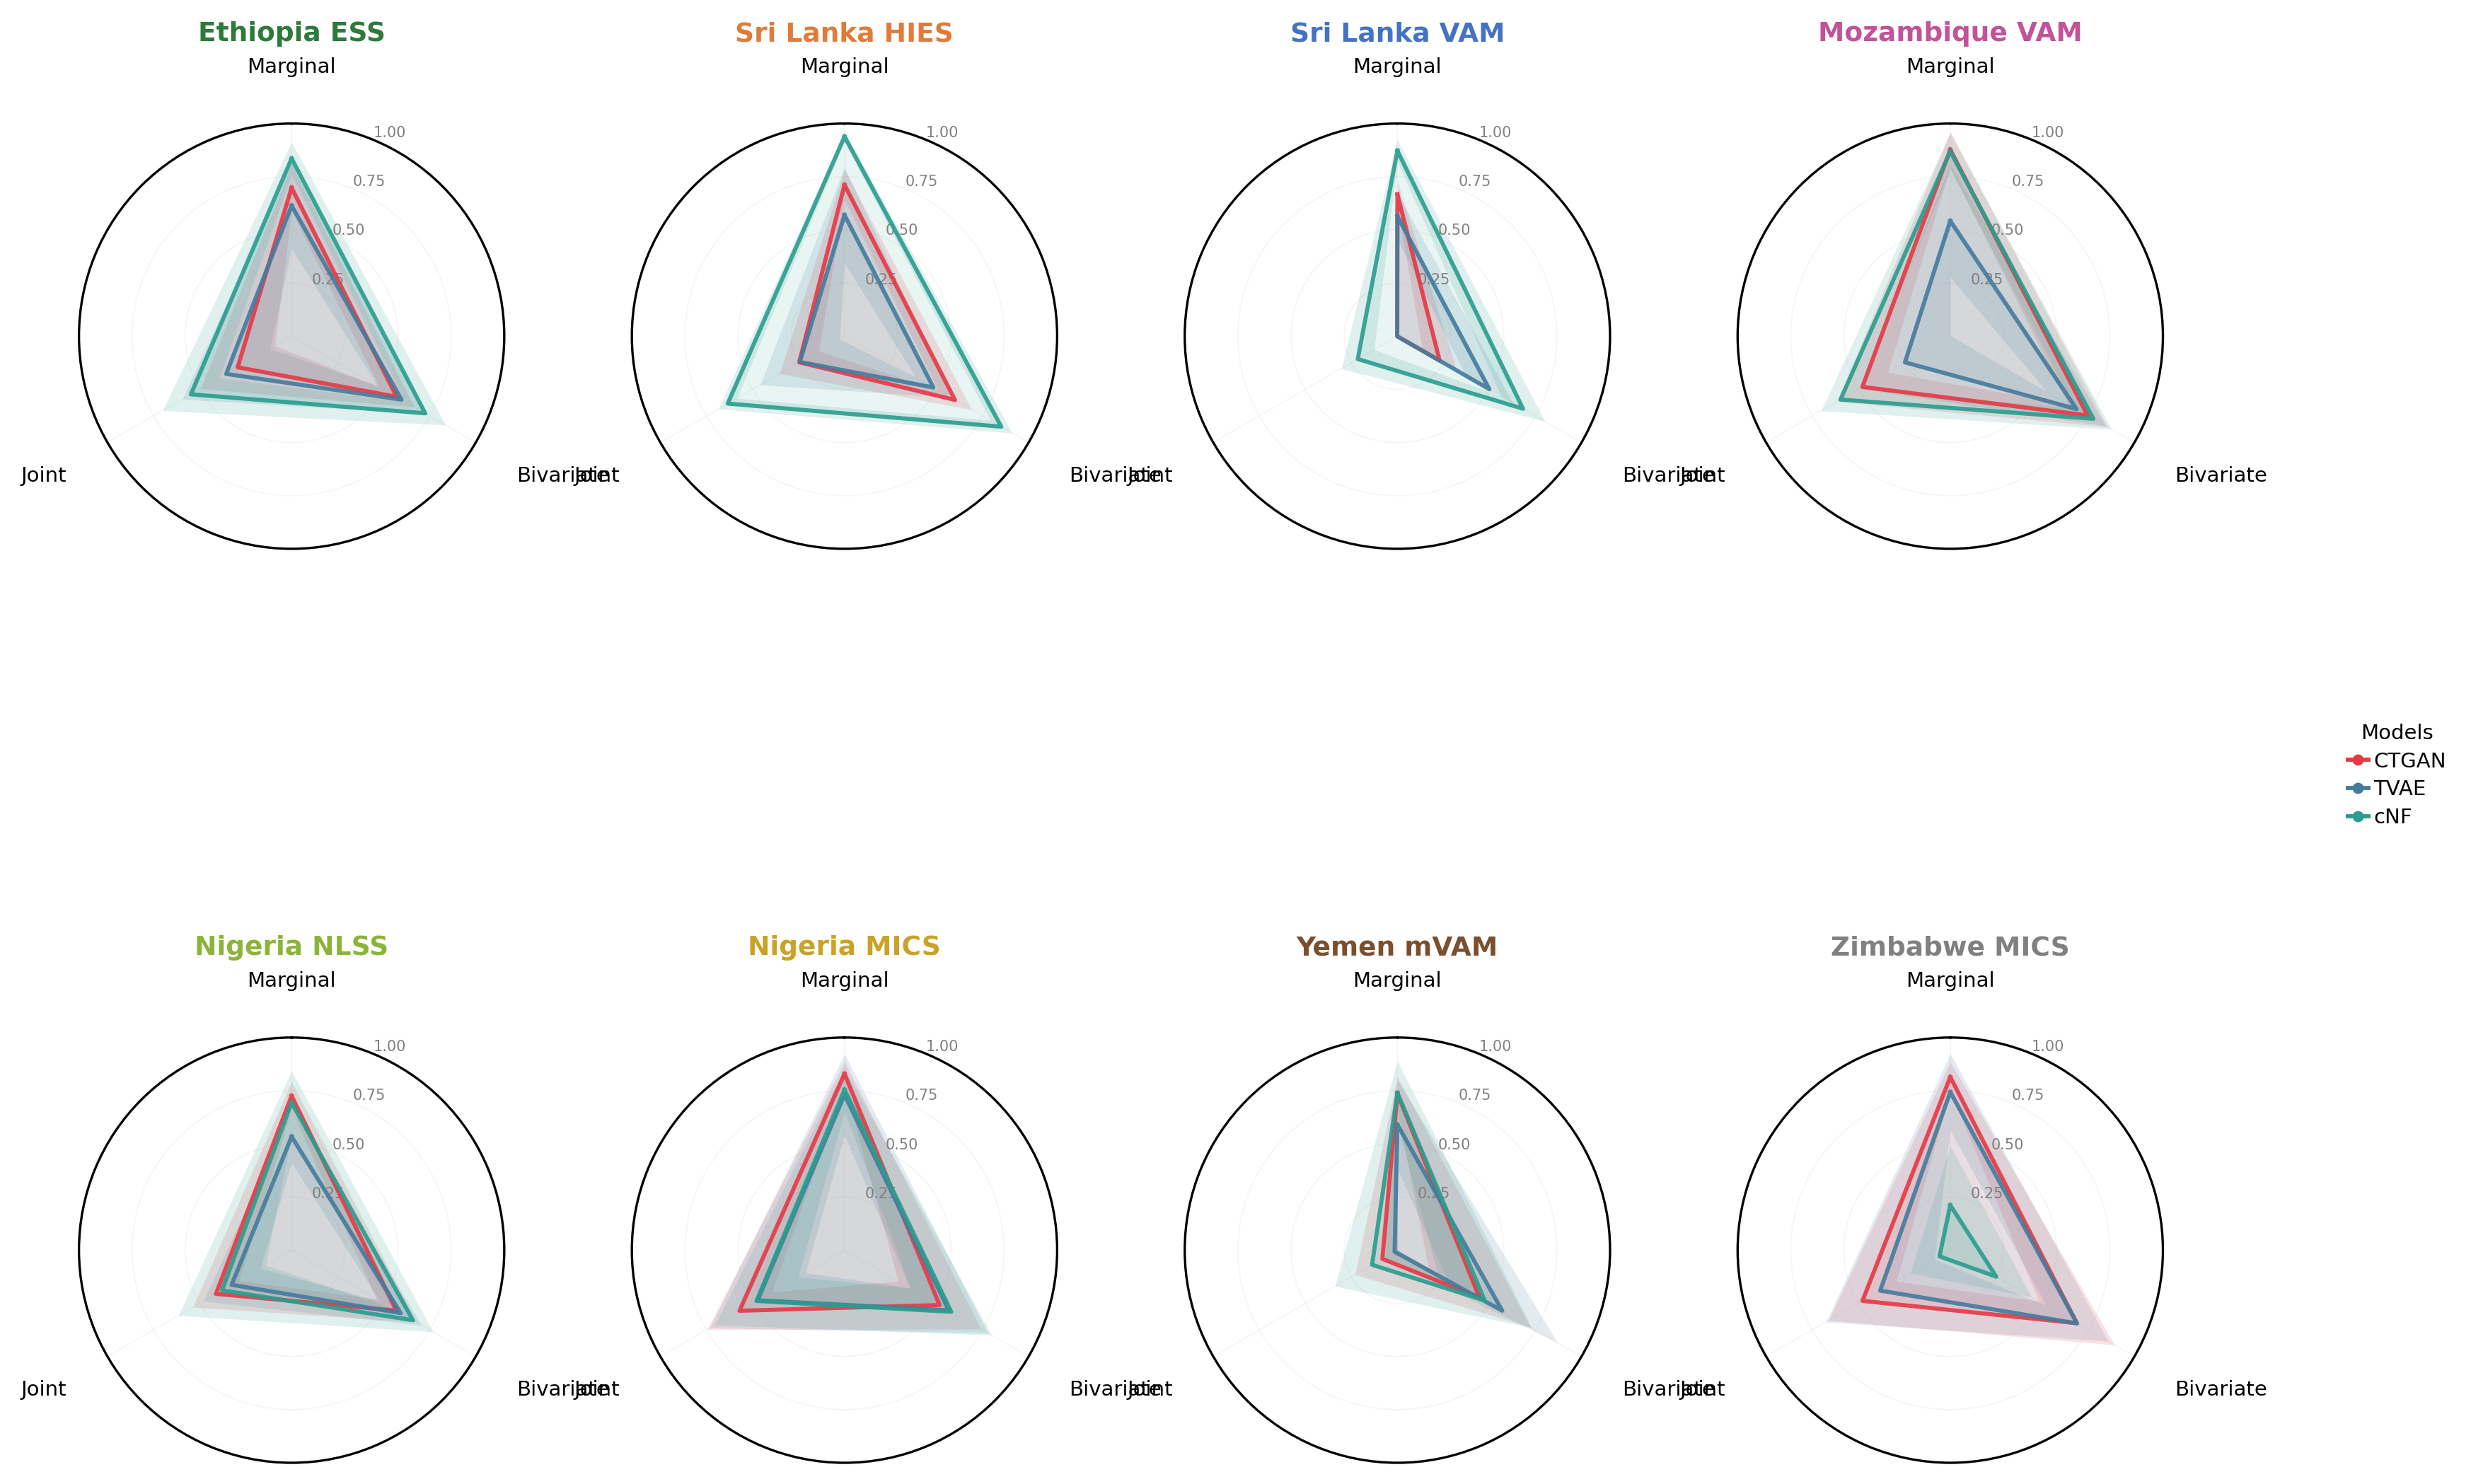

In [22]:
from cycler import cycler

# Pull experiment colors from the Shapley plot style dict
EXPERIMENT_STYLE = {
    "eth_micron": {"color": "#2D7A3A"},
    "lka_micron": {"color": "#E07B39"},
    "lka_vam":    {"color": "#4472C4"},
    "moz_vam":    {"color": "#C2529A"},
    "nga_micron": {"color": "#8DB33A"},
    "nga_mics":   {"color": "#C9A227"},
    "yem_mvam":   {"color": "#7B4F2E"},
    "zwe_mics":   {"color": "#808080"},
}

# Model colors: fixed, clearly distinct, never overlap with exp palette
MODEL_COLORS = {
    "CTGAN": "#E63946",   # red
    "TVAE":  "#457B9D",   # steel blue
    "cNF":   "#2A9D8F",   # teal
}

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

METRICS       = ["marginal_norm", "bivariate_norm", "joint_norm"]
METRIC_LABELS = ["Marginal", "Bivariate", "Joint"]
# angles for a 3-vertex spider, top = Marginal
N      = 3
ANGLES = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
ANGLES_CLOSED = ANGLES + ANGLES[:1]

# precompute where each label sits in (angle, r) for manual text
# Marginal = top (angle=0 after offset), Bivariate = bottom-right, Joint = bottom-left
# We place labels just outside r=1, with per-vertex alignment
LABEL_R = 1.22
LABEL_PROPS = [
    # angle (rad), ha,       va
    (ANGLES[0],   "center", "bottom"),   # Marginal — top
    (ANGLES[1],   "left",   "top"),      # Bivariate — bottom-right
    (ANGLES[2],   "right",  "top"),      # Joint — bottom-left
]

def make_spider(ax, means, stds, models, exp_key):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    # suppress default tick labels; draw manually outside circle
    ax.set_xticks(ANGLES)
    ax.set_xticklabels([])

    for angle, ha, va in LABEL_PROPS:
        label = METRIC_LABELS[ANGLES.index(angle)]
        ax.text(angle, LABEL_R, label,
                ha=ha, va=va, fontsize=7,
                transform=ax.transData)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"],
                       fontsize=5, color="grey")
    ax.grid(True, alpha=0.12, linewidth=0.4)

    exp_color = EXPERIMENT_STYLE[exp_key]["color"]
    label_str = EXP_META[exp_key]["label"]
    ax.set_title(label_str,
                 size=9, fontweight="bold", color=exp_color,
                 pad=28,          # enough room so Marginal label doesn't overlap
                 linespacing=1.4)

    for model in models:
        if model not in means.index:
            continue
        color = MODEL_COLORS[model]
        vals  = (1 - means.loc[model, METRICS]).tolist() + \
                [1 - means.loc[model, METRICS[0]]]
        errs  = stds.loc[model, METRICS].tolist() + \
                [stds.loc[model, METRICS[0]]]

        ax.plot(ANGLES_CLOSED, vals,
                color=color, linewidth=1.4, linestyle="solid",
                label=model, alpha=0.9)
        ax.fill(ANGLES_CLOSED, vals, color=color, alpha=0.10)

        upper = [min(v + e, 1.0) for v, e in zip(vals, errs)]
        lower = [max(v - e, 0.0) for v, e in zip(vals, errs)]
        ax.fill_between(ANGLES_CLOSED, lower, upper,
                        color=color, alpha=0.15, linewidth=0)


# ── Layout matching Shapley reference: explicit subplots_adjust ──────────────
FIG_W, FIG_H = 11.69, 8.27
ncols, nrows = 4, 2

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(FIG_W, FIG_H),
    subplot_kw=dict(polar=True),
    dpi=300,
)
axes = axes.flatten()

for i, exp in enumerate(EXPERIMENTS):
    ax = axes[i]
    if exp not in data:
        ax.set_visible(False)
        continue
    mean_df, std_df = data[exp]
    make_spider(ax, mean_df, std_df, MODELS, exp)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# tight margins, moderate inter-row gap — mirrors Shapley hspace/wspace
fig.subplots_adjust(
    left=0.04, right=0.88,
    top=0.93,  bottom=0.05,
    hspace=0.45, wspace=0.30,
)

# ── Legend: right side, center — mirrors Shapley bbox_to_anchor (1.0, 0.65) ──
handles = [
    plt.Line2D([0], [0], color=MODEL_COLORS[m], linewidth=1.4,
               marker='o', markersize=3.5, label=m)
    for m in MODELS
]
fig.legend(
    handles=handles,
    loc="center right",
    bbox_to_anchor=(1.0, 0.50),
    ncol=1,
    frameon=False,
    fontsize=7,
    handlelength=1.0,
    handletextpad=0.25,
    labelspacing=0.40,
    borderpad=0.2,
    markerscale=0.8,
    title="Models",
    title_fontsize=7,
)

plt.savefig("spider_plots.pdf", bbox_inches="tight", format="pdf")
plt.savefig("spider_plots.png", dpi=300, bbox_inches="tight")
plt.show()

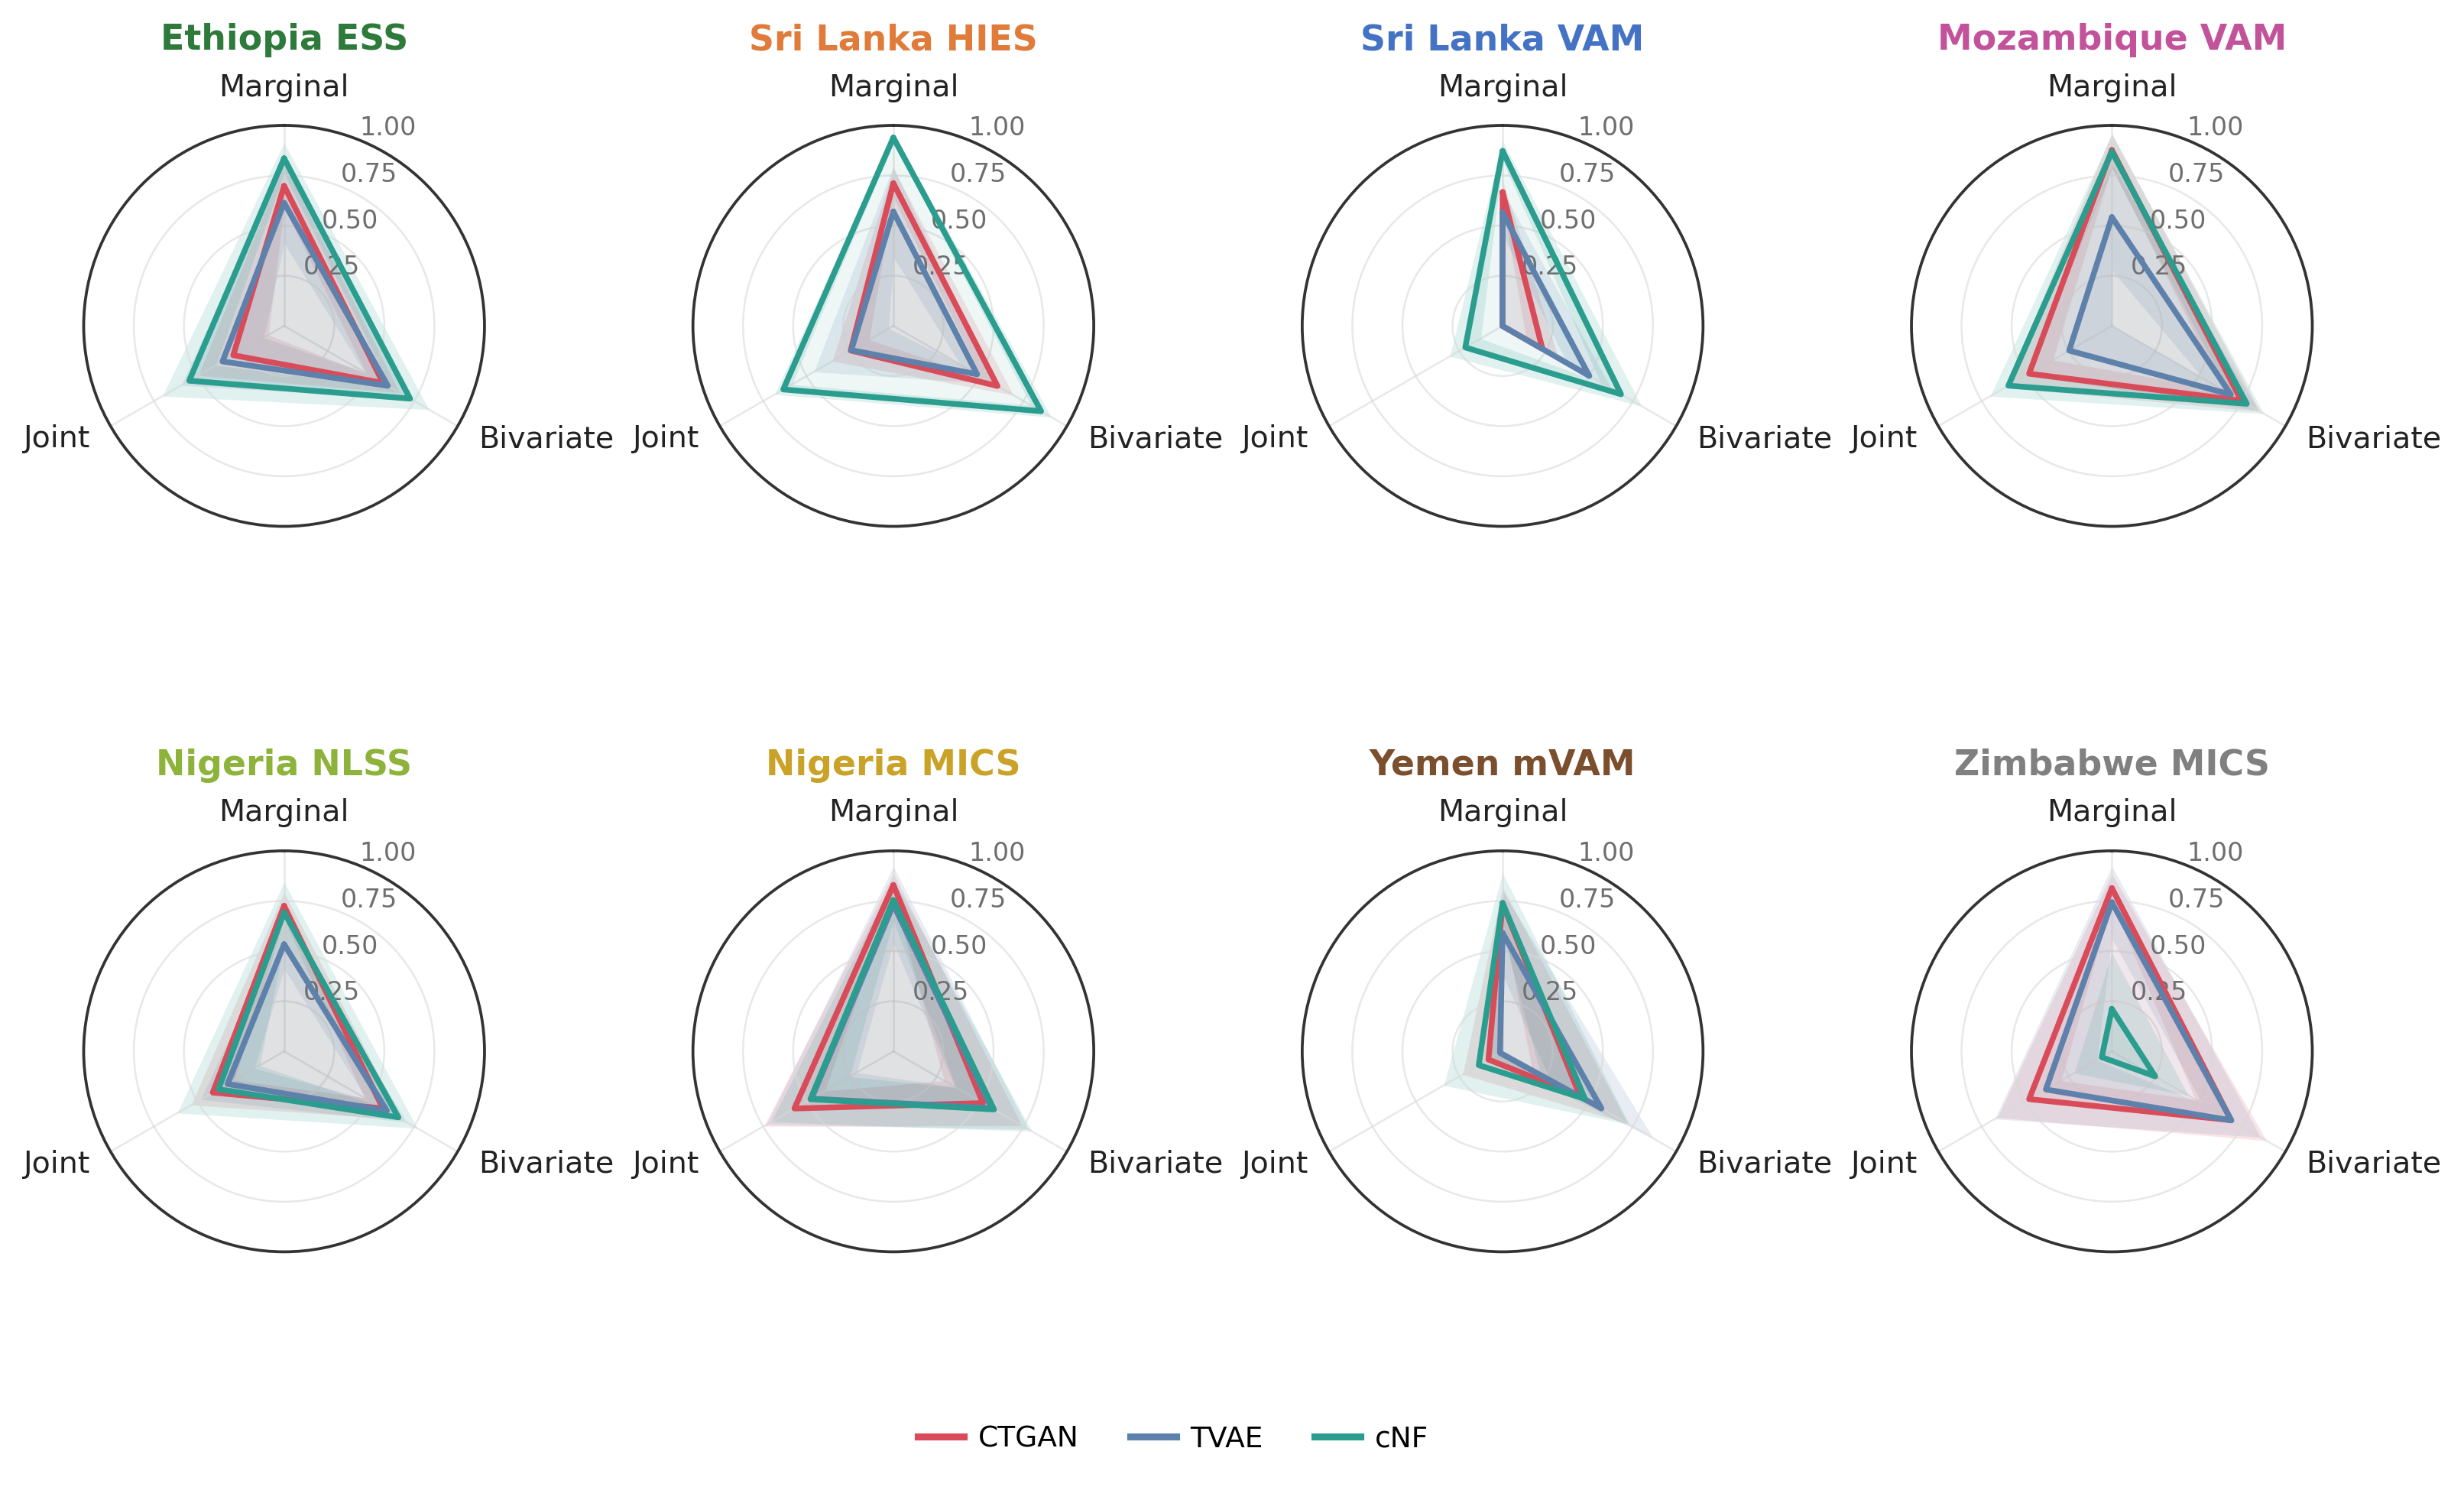

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

# -----------------------------
# Global style
# -----------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
})

MODEL_COLORS = {
    "CTGAN": "#D94B59",
    "TVAE":  "#5E81AC",
    "cNF":   "#2A9D8F",
}

METRICS = ["marginal_norm", "bivariate_norm", "joint_norm"]
METRIC_LABELS = ["Marginal", "Bivariate", "Joint"]

N = len(METRICS)
ANGLES = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
ANGLES_CLOSED = ANGLES + ANGLES[:1]

FIG_W, FIG_H = 10.8, 6.9
ncols, nrows = 4, 2

fig = plt.figure(figsize=(FIG_W, FIG_H), facecolor="white")
gs = gridspec.GridSpec(
    nrows, ncols,
    figure=fig,
    left=0.06, right=0.96,
    top=0.92, bottom=0.16,
    hspace=0.52,
    wspace=0.52,
)

axes = [fig.add_subplot(gs[r, c], polar=True)
        for r in range(nrows) for c in range(ncols)]


def style_radar(ax):
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], color="#6E6E6E")
    ax.set_rlabel_position(22)

    ax.set_xticks(ANGLES)
    ax.set_xticklabels([])

    ax.grid(color="#D9D9D9", alpha=0.6, linewidth=0.6)
    ax.spines["polar"].set_color("#333333")
    ax.spines["polar"].set_linewidth(0.9)
    ax.set_facecolor("white")


def add_axis_labels(ax):
    # Polar coordinates so labels stay attached to the circle
    r_lab = 1.12
    label_specs = [
        (ANGLES[0], r_lab, "Marginal",  "center", "bottom"),
        (ANGLES[1], r_lab, "Bivariate", "left",   "center"),
        (ANGLES[2], r_lab, "Joint",     "right",  "center"),
    ]

    for theta, r, txt, ha, va in label_specs:
        ax.text(
            theta, r, txt,
            ha=ha, va=va,
            fontsize=9.5,
            color="#222222",
            clip_on=False,
        )


def make_spider(ax, means, stds, models, exp_key):
    style_radar(ax)

    exp_color = EXPERIMENT_STYLE[exp_key]["color"]
    label_str = EXP_META[exp_key]["label"]

    ax.set_title(label_str, color=exp_color, pad=24)

    for model in models:
        if model not in means.index:
            continue

        color = MODEL_COLORS[model]

        vals = (1 - means.loc[model, METRICS]).tolist()
        vals_closed = vals + vals[:1]

        errs = stds.loc[model, METRICS].tolist()
        errs_closed = errs + errs[:1]

        upper = [min(v + e, 1.0) for v, e in zip(vals_closed, errs_closed)]
        lower = [max(v - e, 0.0) for v, e in zip(vals_closed, errs_closed)]

        ax.fill(
            ANGLES_CLOSED, vals_closed,
            color=color, alpha=0.08, zorder=2
        )
        ax.fill_between(
            ANGLES_CLOSED, lower, upper,
            color=color, alpha=0.14, linewidth=0, zorder=1
        )
        ax.plot(
            ANGLES_CLOSED, vals_closed,
            color=color, linewidth=1.8,
            solid_capstyle="round",
            zorder=3
        )

    add_axis_labels(ax)


for i, exp in enumerate(EXPERIMENTS):
    ax = axes[i]
    if exp not in data:
        ax.set_visible(False)
        continue

    mean_df, std_df = data[exp]
    make_spider(ax, mean_df, std_df, MODELS, exp)

for j in range(len(EXPERIMENTS), len(axes)):
    axes[j].set_visible(False)


# Bottom-centered legend
handles = [
    Line2D([0], [0], color=MODEL_COLORS[m], lw=2.2, label=m)
    for m in MODELS
]

fig.legend(
    handles=handles,
    labels=MODELS,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    frameon=False,
    handlelength=1.6,
    handletextpad=0.5,
    columnspacing=1.8,
    borderaxespad=0.0,
)

plt.savefig("spider_plots_fixed.png", bbox_inches="tight")
plt.savefig("spider_plots_fixed.pdf", bbox_inches="tight")
plt.show()

In [24]:
RECALL_BASE = Path("/data/shared/fsibilla/clean_code/Q0/recall")

def load_recall(exp):
    path = RECALL_BASE / exp / "recall_gen_true_overall.csv"
    df = pd.read_csv(path)
    # average over seeds
    mean = df.groupby("model")["recall"].mean()
    std  = df.groupby("model")["recall"].std()
    return mean, std

recall_data = {}
for exp in EXPERIMENTS:
    try:
        recall_data[exp] = load_recall(exp)
    except FileNotFoundError:
        print(f"Missing recall: {exp}")

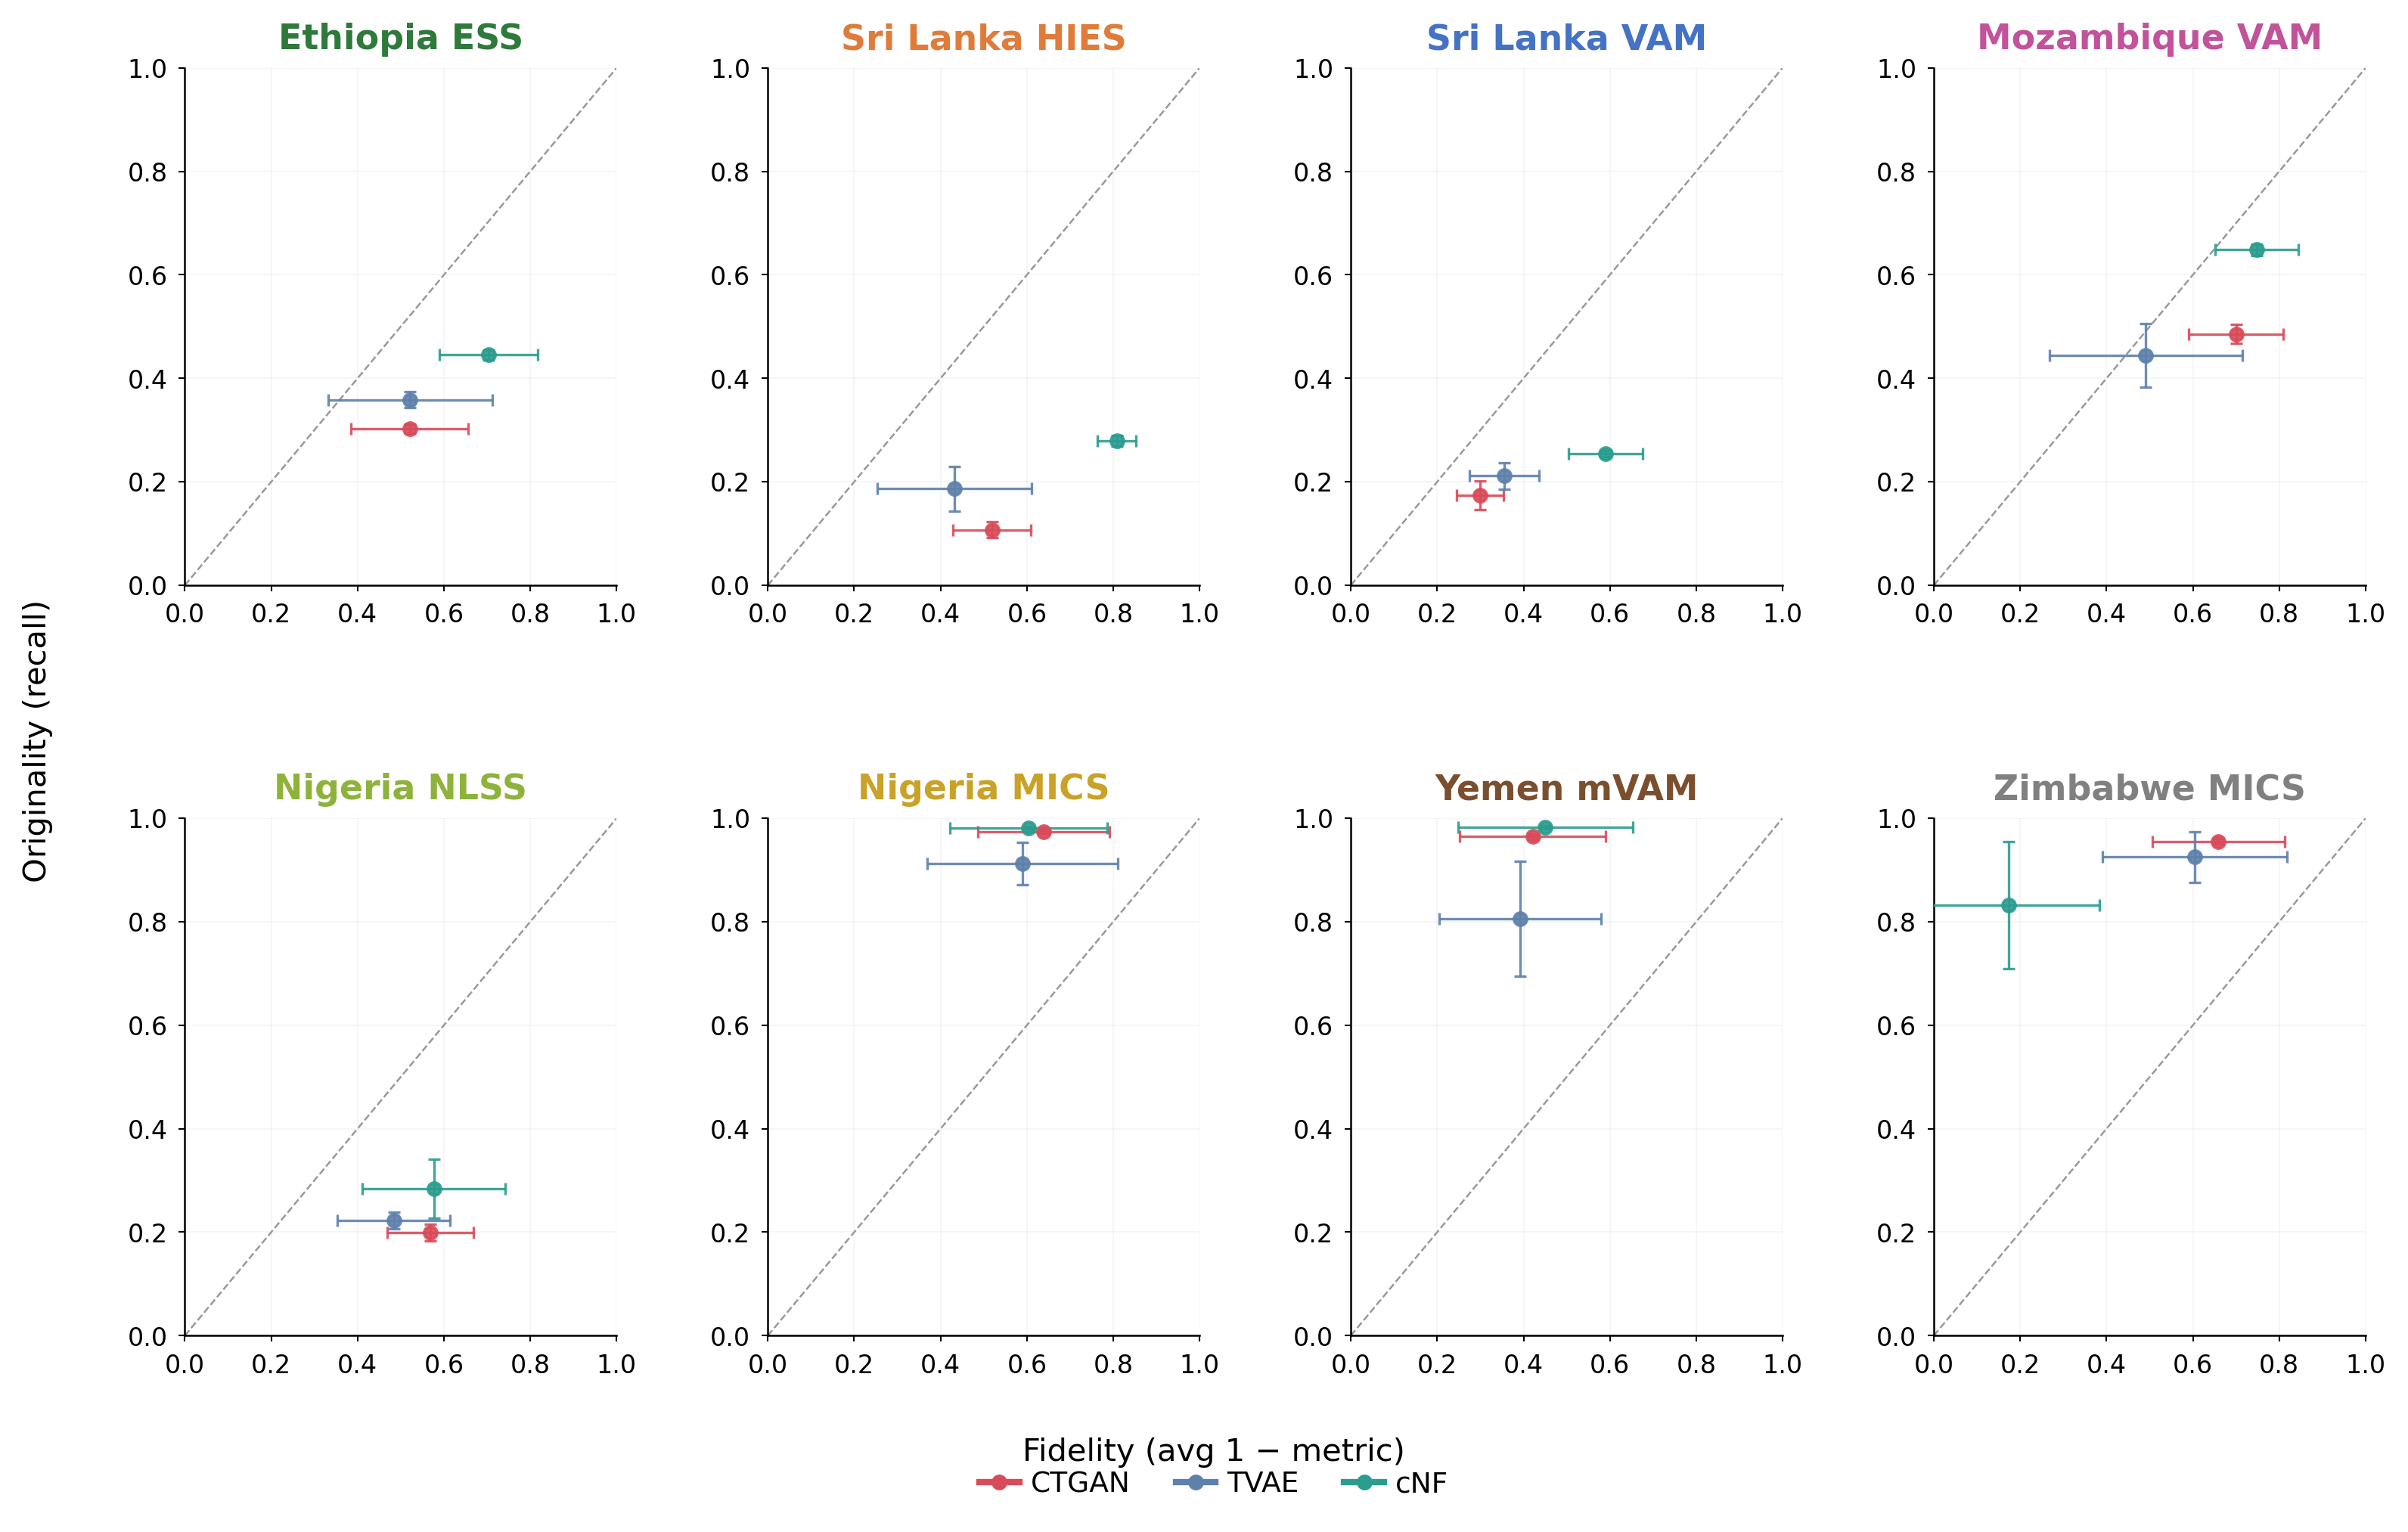

In [25]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(FIG_W, FIG_H),
    dpi=300,
)
axes = axes.flatten()

for i, exp in enumerate(EXPERIMENTS):
    ax = axes[i]
    if exp not in data or exp not in recall_data:
        ax.set_visible(False)
        continue

    mean_df, std_df   = data[exp]
    rec_mean, rec_std = recall_data[exp]

    exp_color = EXPERIMENT_STYLE[exp]["color"]
    label_str = EXP_META[exp]["label"]

    for model in MODELS:
        if model not in mean_df.index or model not in rec_mean.index:
            continue

        # Fidelity: mean of (1 - metric) over the 3 metrics
        fid_val = (1 - mean_df.loc[model, METRICS]).mean()
        fid_err = std_df.loc[model, METRICS].mean()

        rec_val = rec_mean.loc[model]
        rec_err = rec_std.loc[model] if not np.isnan(rec_std.loc[model]) else 0.0

        color = MODEL_COLORS[model]
        ax.errorbar(
            fid_val, rec_val,
            xerr=fid_err, yerr=rec_err,
            fmt="o", color=color,
            markersize=4, linewidth=1.2,
            elinewidth=0.8, capsize=2, capthick=0.8,
            alpha=0.9, zorder=3,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axline((0, 0), slope=1, color="black", linestyle="--",
              linewidth=0.6, alpha=0.4, zorder=1)

    ax.set_title(label_str, color=exp_color,
                 fontsize=11, fontweight="bold", pad=6, linespacing=1.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.grid(True, alpha=0.12, linewidth=0.4)
    ax.tick_params(labelsize=8, width=0.5, length=2)

for j in range(len(EXPERIMENTS), len(axes)):
    axes[j].set_visible(False)

# Shared axis labels
fig.text(0.5,  0.04, "Fidelity (avg 1 − metric)",  ha="center", fontsize=10)
fig.text(0.02, 0.5,  "Originality (recall)",        ha="center", fontsize=10,
         rotation=90, va="center")

handles = [Line2D([0], [0], color=MODEL_COLORS[m], lw=2, marker="o",
                  markersize=4, label=m) for m in MODELS]
fig.legend(
    handles=handles, labels=MODELS,
    loc="lower center", bbox_to_anchor=(0.5, 0.0),
    ncol=3, frameon=False,
    handlelength=1.4, handletextpad=0.4, columnspacing=1.6,
)

fig.subplots_adjust(
    left=0.08, right=0.97,
    top=0.93,  bottom=0.12,
    hspace=0.45, wspace=0.35,
)

plt.savefig("fidelity_originality_scatter.png", bbox_inches="tight")
plt.savefig("fidelity_originality_scatter.pdf", bbox_inches="tight")
plt.show()

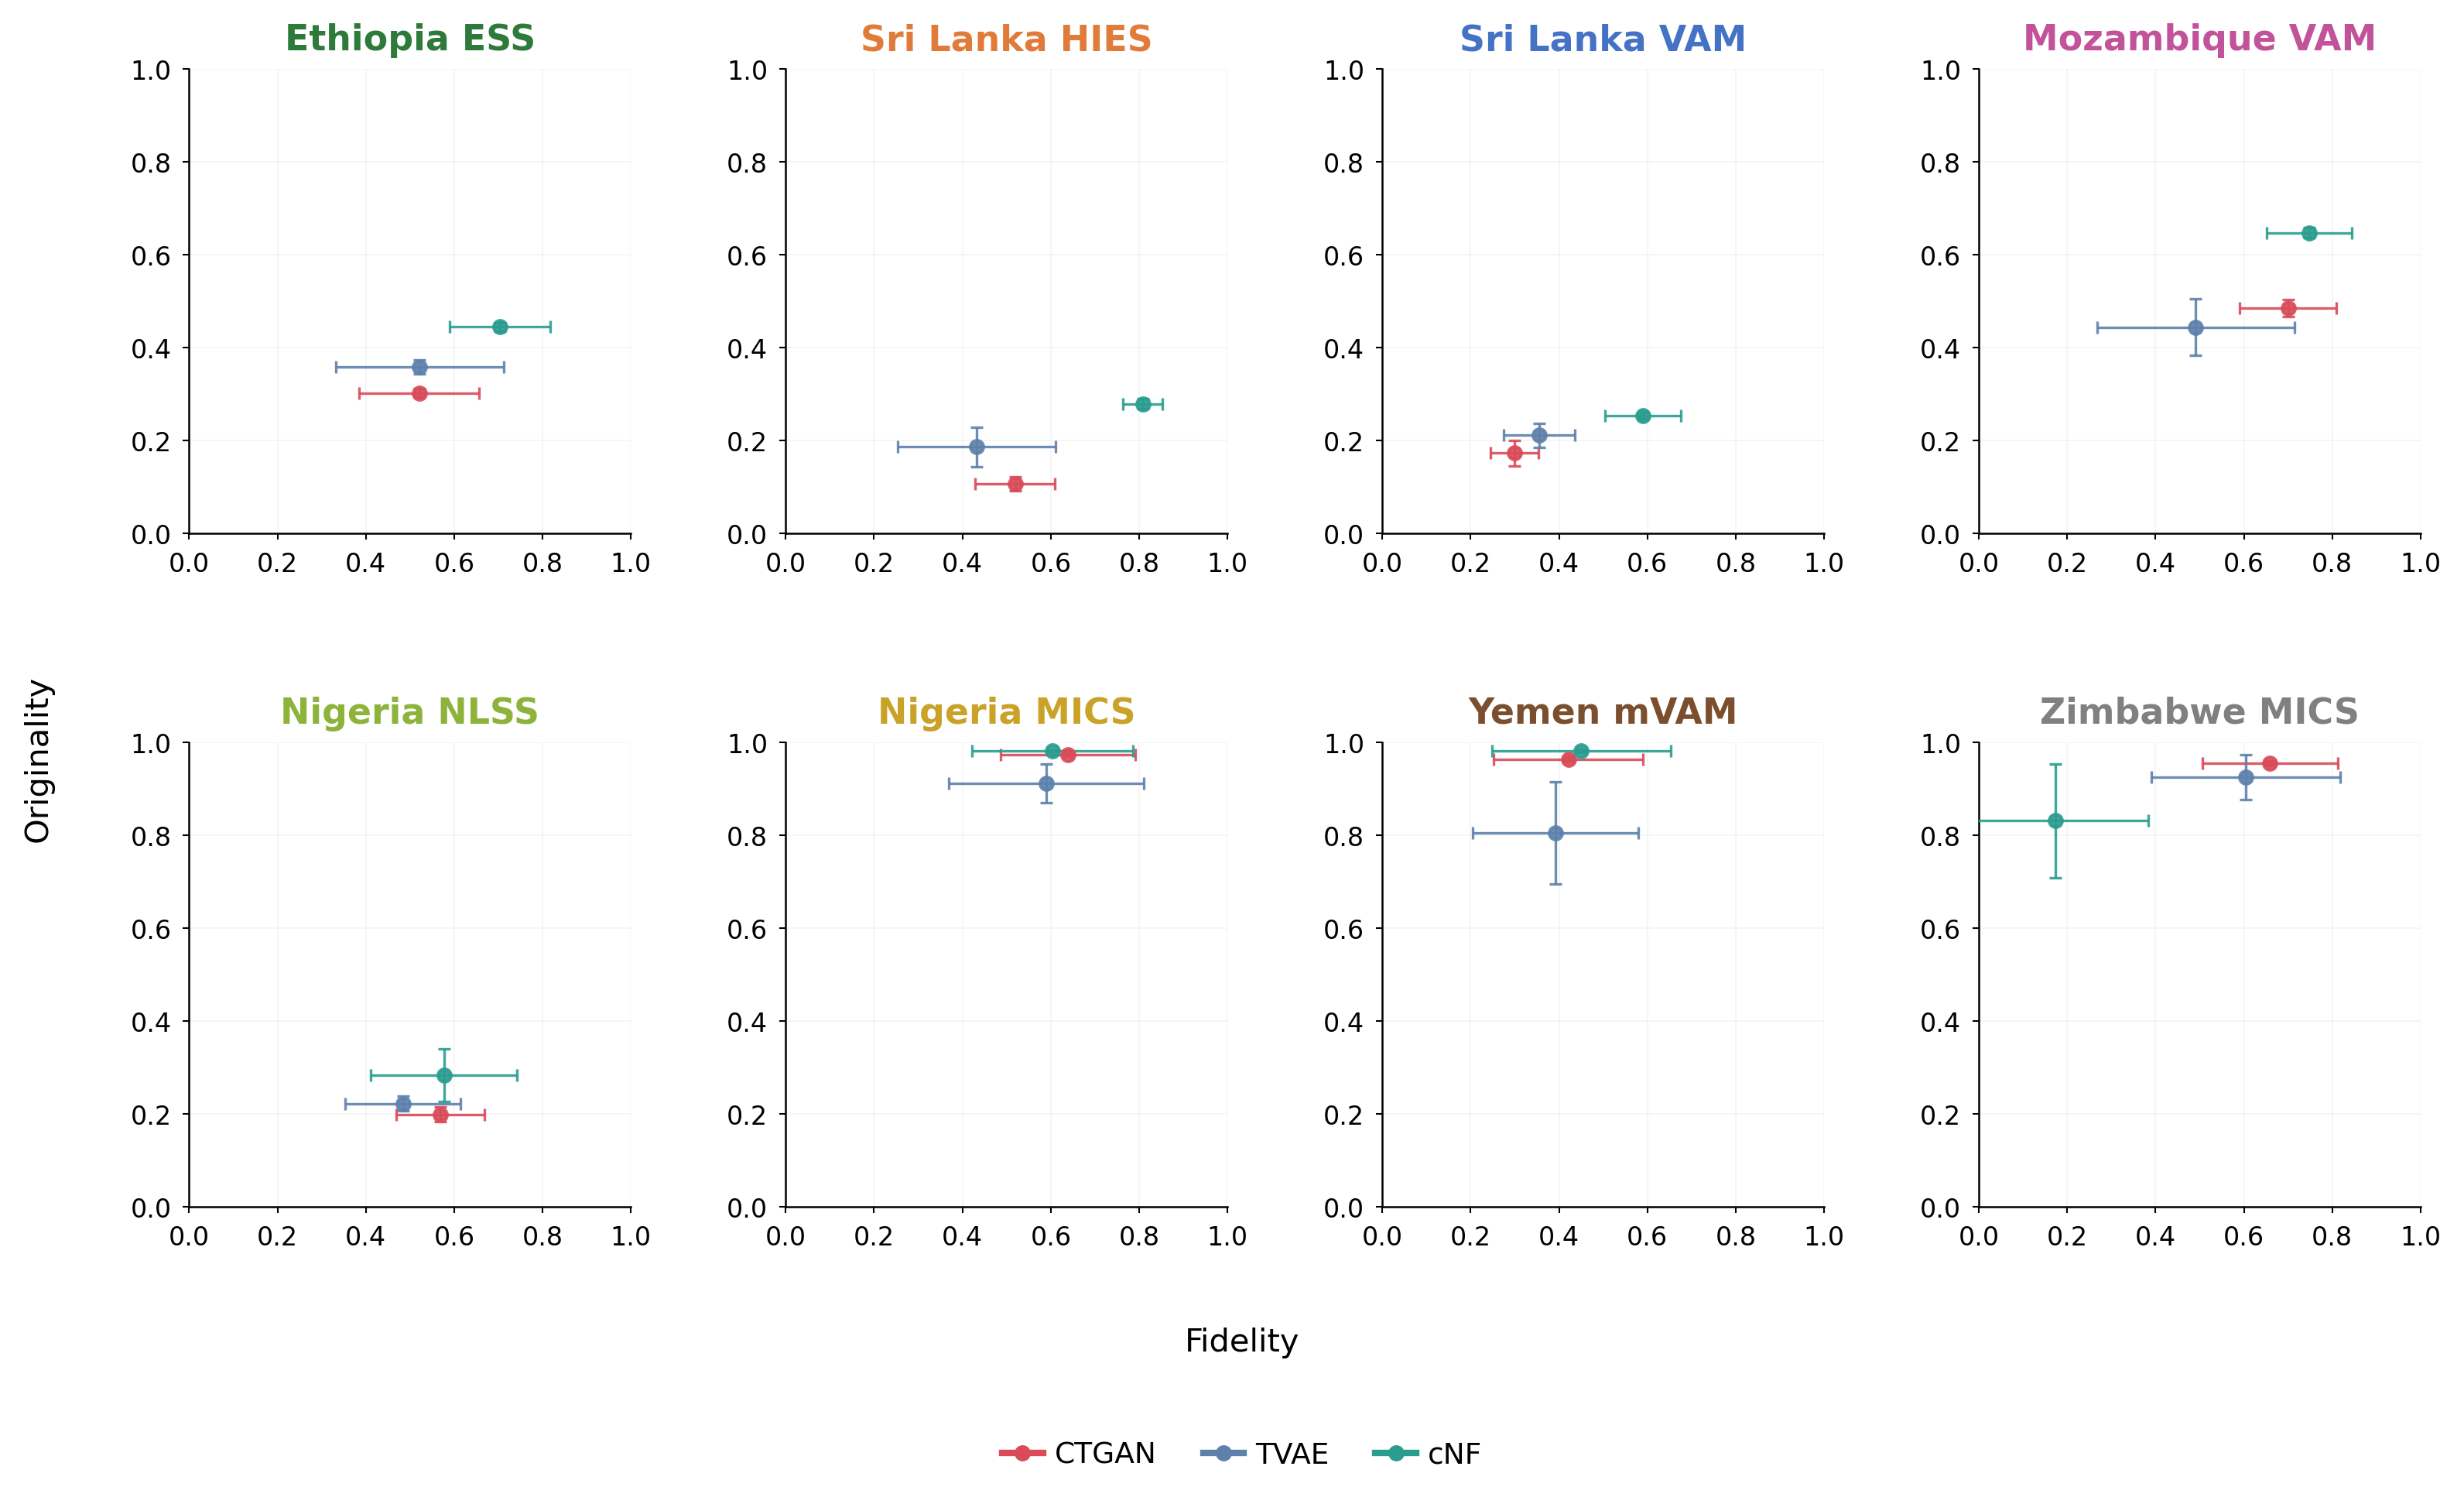

In [29]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(FIG_W, FIG_H),
    dpi=300,
)
axes = axes.flatten()

for i, exp in enumerate(EXPERIMENTS):
    ax = axes[i]
    if exp not in data or exp not in recall_data:
        ax.set_visible(False)
        continue

    mean_df, std_df   = data[exp]
    rec_mean, rec_std = recall_data[exp]

    exp_color = EXPERIMENT_STYLE[exp]["color"]
    label_str = EXP_META[exp]["label"]

    for model in MODELS:
        if model not in mean_df.index or model not in rec_mean.index:
            continue

        fid_val = (1 - mean_df.loc[model, METRICS]).mean()
        fid_err = std_df.loc[model, METRICS].mean()

        rec_val = rec_mean.loc[model]
        rec_err = rec_std.loc[model] if not np.isnan(rec_std.loc[model]) else 0.0

        color = MODEL_COLORS[model]
        ax.errorbar(
            fid_val, rec_val,
            xerr=fid_err, yerr=rec_err,
            fmt="o", color=color,
            markersize=4, linewidth=1.2,
            elinewidth=0.8, capsize=2, capthick=0.8,
            alpha=0.9, zorder=3,
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_title(label_str, color=exp_color,
                 fontsize=11, fontweight="bold", pad=6, linespacing=1.4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.grid(True, alpha=0.12, linewidth=0.4)
    ax.tick_params(labelsize=8, width=0.5, length=2)

for j in range(len(EXPERIMENTS), len(axes)):
    axes[j].set_visible(False)
fig.text(0.5,  0.13, "Fidelity", ha="center", fontsize=10)
fig.text(0.02, 0.5,  "Originality",       ha="center", fontsize=10,
         rotation=90, va="center")

fig.subplots_adjust(
    left=0.08, right=0.97,
    top=0.93,  bottom=0.22,
    hspace=0.45, wspace=0.35,
)

fig.legend(
    handles=handles, labels=MODELS,
    loc="lower center", bbox_to_anchor=(0.5, 0.04),
    ncol=3, frameon=False,
    handlelength=1.4, handletextpad=0.4, columnspacing=1.6,
)
plt.savefig("fidelity_originality_scatter.png", bbox_inches="tight")
plt.savefig("fidelity_originality_scatter.pdf", bbox_inches="tight")
plt.show()